In [20]:
import json
import pandas as pd
from typing import Dict, List, Any
import numpy as np

def extract_gtfs(file_path):
    json_data = Dict[str, Any]
    with open(file_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)

    normalized_data = []
    for poi in json_data['elements']:
        # Copy basic properties like type, id, lat, lon
        item = {k: v for k, v in poi.items() if k != 'tags'}
        if 'tags' in poi and isinstance(poi['tags'], dict):
            item.update(poi['tags'])

        normalized_data.append(item)

    df = pd.DataFrame(normalized_data)
    df = df.replace('nan', np.nan)

    if not df.empty:
        priority_cols = ['id', 'name', 'lat', 'lon', 'opening_hours', 'amenity', 'cuisine', 'wheelchair', 'toilets', 'access']
        existing_cols = [col for col in priority_cols if col in df.columns]
        other_cols = [col for col in df.columns if col not in existing_cols]
        df = df[existing_cols + other_cols]

    return df

file_path = '../data_collection/raw_data/raw_osm.json'
data_df = extract_gtfs(file_path)

## Important Accessibility related tags

* wheelchair
* toilets
* toilets:unisex
* toilets:wheelchair
* changing_table
* sensory_friendly:accommodation
* drive_through
* air_conditioning

## Rule-based Scheduler

In [21]:
import pandas as pd
from typing import List, Dict, Optional, Any
import math

class ItineraryScheduler:
    def __init__(self, data_df):
        self.data_df = data_df.copy().reset_index(drop=True)
        self.data_df['lat'] = pd.to_numeric(self.data_df['lat'], errors='coerce')
        self.data_df['lon'] = pd.to_numeric(self.data_df['lon'], errors='coerce')
        # self.data_df.dropna(subset=['lat', 'lon'], inplace=True)

    @staticmethod
    def calculate_distance(lat1, lon1, lat2, lon2):
        radius = 3958.8  #miles
        
        lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
        lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
        
        d_lat = lat2_rad - lat1_rad
        d_lon = lon2_rad - lon1_rad
        
        # Haversine formula
        a = math.sin(d_lat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(d_lon / 2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
        
        return radius * c
    
    def update_basic_score(self, df, accessibility_needs):
        df['base_score'] = 0
        helpful_tags = ['opening_hours', 'phone', 'website']
        for ht in helpful_tags:
            df.loc[df[ht].notna(), 'base_score'] += 1

        features = accessibility_needs.split("|")
        for accessibility_feature in features:
            df.loc[df[accessibility_feature].isin(['yes', 'designated']), 'base_score'] += 2
        
        return df
    

    def rule_based_decision(self, prefs, poi_type):
        pois = self.data_df.copy()
        pois = self.update_basic_score(pois, prefs['required_accessibility'])

        # check for poi type
        if poi_type == 'amenity':
            pois = pois[
                pois['amenity'].str.contains(prefs['amenity_type'], case=False, na=False)
            ]
        elif poi_type == 'tourism':
            pois = pois[
                pois['tourism'].str.contains(prefs['tourism_type'], case=False, na=False)
            ]
        
        # check for cuisine
        if 'cuisine' in prefs:
            not_restuarant = (pois['amenity'] != 'restaurant')
            restaurant_with_cuisine = (
                (pois['amenity'] == 'restaurant') & 
                (pois['cuisine'].str.contains(prefs['cuisine'], case=False, na=False))
            )
            pois = pois[not_restuarant | restaurant_with_cuisine]

        # check for accesibility
        features = prefs.get('required_accessibility').split("|")
        for accessibility_feature in features:
            pois = pois[
                pois[accessibility_feature].isin(['yes', 'designated'])
            ]

        # Remove items already visited
        if 'visited_ids' in prefs:
            pois = pois[~pois['id'].isin(prefs['visited_ids'])]

        return pois

    def create_itinerary(self, prefs, verbose=True):        
        itinerary = []
        start_lat = prefs['start_location']['lat']
        start_lon = prefs['start_location']['lon']
        num_pois = prefs['num_poi']
        time_per_poi_hrs, max_travel_mi = prefs['time_per_poi'], prefs['max_travel_dist']
        curr_lat, curr_lon = start_lat, start_lon
        
        travel_time = num_pois * 0.5 # estimate 30 min for moving
        total_estimated_time = (num_pois * time_per_poi_hrs) + travel_time
        
        # Limit possible time
        if total_estimated_time > 12:
            #  return [{"Error": "Requested trip is too ambitious for one day (" + str(total_estimated_time) + " hours needed). Reduce the number of POIs."}]
            num_pois -= 1

        for i in range(num_pois):
            poi_type = 'amenity' if i % 2 == 0 else 'tourism'
            pois = self.rule_based_decision(prefs, poi_type)
            
            if pois.empty:
                if verbose:
                    print(f"No more pois matching prefs.")
                break

            pois['dist'] = pois.apply(
                lambda row: self.calculate_distance(curr_lat, curr_lon, row['lat'], row['lon']),
                axis=1
            )

            # only consider poi within range limit
            pois = pois[pois['dist'] <= max_travel_mi]
            
            if pois.empty:
                if verbose:
                    print(f"Warning: Stopped at POI {i+1}. No nearby POIs found (max {max_travel_mi} mi).")
                break

            
            # Get final score and sort
            pois['final_score'] = pois['base_score'] - (pois['dist'] * 0.1) 
            best_choice = pois.sort_values(by='final_score', ascending=False).iloc[0]

            chosen_poi = {
                "id": int(best_choice['id']),
                "name": best_choice['name'],
                "lat": best_choice['lat'],
                "lon": best_choice['lon'],
                "poi_type": poi_type,
                "dist_from_prev": round(best_choice['dist'], 2),
                "duration": f"{time_per_poi_hrs} hours",
                "score": round(best_choice['final_score'], 2),
                "cuisine": best_choice.get('cuisine', 'N/A'),
                "amenity": best_choice.get('amenity', 'N/A'),
                "tourism": best_choice.get('tourism', 'N/A'),
                "features": {
                    "wheelchair": best_choice.get('wheelchair', 'False'),
                }
            }

            itinerary.append(chosen_poi)

            # update
            curr_lat = best_choice['lat']
            curr_lon = best_choice['lon']
            prefs['visited_ids'].add(best_choice['id'])

        return itinerary

## Run Rule-Based Scheduler

In [22]:
# User-inputted variables
START_LAT = 32.5106
START_LON = -117.0626 
NUM_POIS_TO_VISIT = 4
TIME_PER_POI = 1.5
MAX_DIST = 15

# User Preferences
USER_PREFERNCES = {
    "start_location": {"lat": START_LAT, "lon": START_LON},
    "num_poi": NUM_POIS_TO_VISIT,
    "time_per_poi": TIME_PER_POI,
    "max_travel_dist": MAX_DIST,
    "avg_travel_speed_mph": 20.0, 
    "max_travel_time_minutes": 45.0,
    "amenity_type": "restaurant|theatre|cafe", #'fast_food', 'restaurant', 'cafe', 'post_office', 'fountain', 'bench', 'theatre', 'clock', 'bicycle_parking', 'planetarium', 'conference_centre', 'fire_station', 'cinema', 'toilets', 'arts_centre', 'place_of_worship'
    "tourism_type": "museum|gallery|viewpoint|attraction|aquarium", # 'attraction', 'gallery', 'museum', 'viewpoint', 'artwork', 'aquarium', 'zoo', 'theme_park'
    "cuisine": "italian|mexican|american",
    "required_accessibility": "wheelchair", #"wheelchair|toilets:wheelchair"
    "visited_ids": set()
}

# Scheduler
scheduler = ItineraryScheduler(data_df)
print(f"Starting Location: ({START_LAT}, {START_LON})")
print(f"Generating Itinerary for {NUM_POIS_TO_VISIT} Points of Interest...")
print("-" * 80)

itinerary = scheduler.create_itinerary(USER_PREFERNCES)

# Result
for i, poi in enumerate(itinerary):
    if i == 0:
        dist = f"Start: ({round(START_LAT, 4)}, {round(START_LON, 4)})"
    else:
        dist = f"From Previous: {poi['dist_from_prev']} mi"

    print(f"POI {i + 1}: {poi['name']} ({poi['poi_type']})")
    print(f"  - Location: ({poi['lat']}, {poi['lon']}) ({dist})")
    print(f"  - Duration: {poi['duration']}")
    print(f"  - Final Score: {poi['score']}\n")

Starting Location: (32.5106, -117.0626)
Generating Itinerary for 4 Points of Interest...
--------------------------------------------------------------------------------
POI 1: Cafe X: By Any Beans Necessary (amenity)
  - Location: (32.7061667, -117.1470126) (Start: (32.5106, -117.0626))
  - Duration: 1.5 hours
  - Final Score: 3.56

POI 2: San Diego History Center (tourism)
  - Location: (32.7311591, -117.148272) (From Previous: 1.73 mi)
  - Duration: 1.5 hours
  - Final Score: 3.83

POI 3: Modern Times Coffee (amenity)
  - Location: (32.7118498, -117.1562868) (From Previous: 1.41 mi)
  - Duration: 1.5 hours
  - Final Score: 4.86



## Evaluation

In [23]:
from evaluation import get_evaluation_metrics_verbose, get_evaluation_metrics

In [24]:
metrics = get_evaluation_metrics_verbose(itinerary, USER_PREFERNCES)


--------------------------------------------------------------------------------
Itinerary
--------------------------------------------------------------------------------
Total POIs: 3
User Preferences: {'start_location': {'lat': 32.5106, 'lon': -117.0626}, 'num_poi': 4, 'time_per_poi': 1.5, 'max_travel_dist': 15, 'avg_travel_speed_mph': 20.0, 'max_travel_time_minutes': 45.0, 'amenity_type': 'restaurant|theatre|cafe', 'tourism_type': 'museum|gallery|viewpoint|attraction|aquarium', 'cuisine': 'italian|mexican|american', 'required_accessibility': 'wheelchair', 'visited_ids': {np.int64(6579135920), np.int64(12737932052), np.int64(12996157247)}}
Required Features: wheelchair

--------------------------------------------------------------------------------
Quality of POI Metric
--------------------------------------------------------------------------------
Total Travel Distance: 17.52 miles
Total Travel Time: 52.6 minutes (Max: 45.0 min)
Travel Distance/Time Score: -0.17
POI Diversity Sc

## Using Test Data

In [25]:
scheduler = ItineraryScheduler(data_df)

test_filename = '../testing/user_preferences_100.json'
with open(test_filename, 'r', encoding='utf-8') as f:
    test_set = json.load(f)

itinerary_metrics = []
itinerary_metrics_success = []

for user_pref in test_set:
    user_pref['visited_ids'] = set()
    itinerary = scheduler.create_itinerary(user_pref, verbose=False)

    # Result
    # for i, poi in enumerate(itinerary):
    #     if i == 0:
    #         dist = f"Start: ({round(user_pref['start_location']['lat'], 4)}, {round(user_pref['start_location']['lon'], 4)})"
    #     else:
    #         dist = f"From Previous: {poi['dist_from_prev']} mi"

    #     print(f"POI {i + 1}: {poi['name']} ({poi['poi_type']})")
    #     print(f"  - Location: ({poi['lat']}, {poi['lon']}) ({dist})")
    #     print(f"  - Duration: {poi['duration']}")
    #     print(f"  - Final Score: {poi['score']}\n")

    metrics = get_evaluation_metrics(itinerary, user_pref)
    itinerary_metrics.append(metrics)
    if sum(metrics) != 0:
        itinerary_metrics_success.append(metrics)

## Visualization

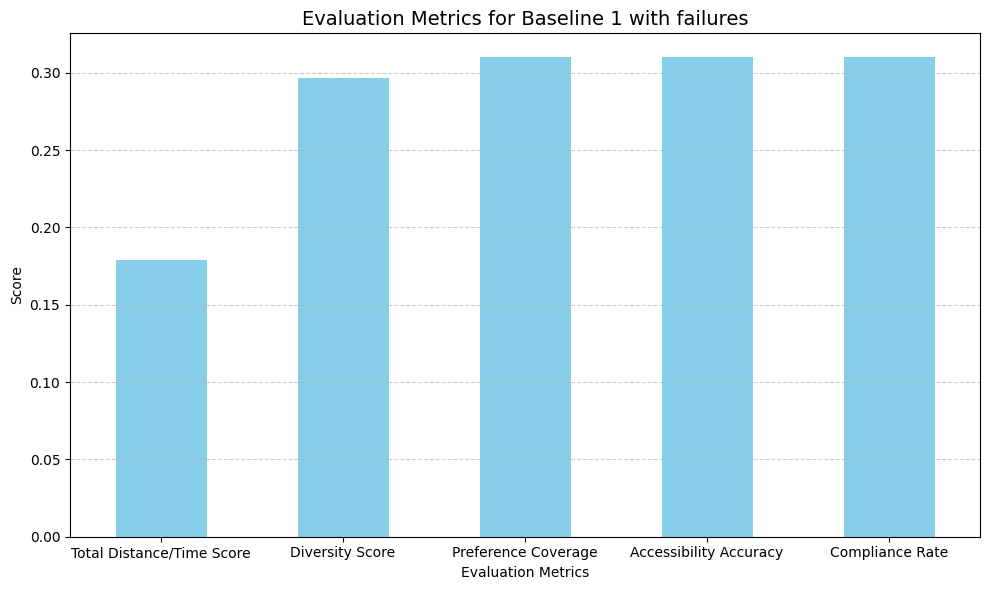

In [26]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.DataFrame(itinerary_metrics)
avg = df.mean(axis=0)
avg = avg.drop(index=[1, 2])
labels = ['Total Distance/Time Score', 'Diversity Score', 'Preference Coverage', 'Accessibility Accuracy', 'Compliance Rate']

plt.figure(figsize=(10, 6))
ax = avg.plot(kind='bar', color='skyblue')
ax.set_xticklabels(labels)
plt.title('Evaluation Metrics for Baseline 1 with failures', fontsize=14)
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# df = pd.DataFrame(itinerary_metrics_success)
# avg = df.mean(axis=0)
# avg = avg.drop(index=[1, 2])

# plt.figure(figsize=(10, 6))
# ax = avg.plot(kind='bar', color='darkgreen')
# ax.set_xticklabels(labels)
# plt.title('Evaluation Metrics for Baseline 1 without failures', fontsize=14)
# plt.xlabel('Evaluation Metrics')
# plt.ylabel('Score')
# plt.xticks(rotation=0)
# plt.tight_layout()


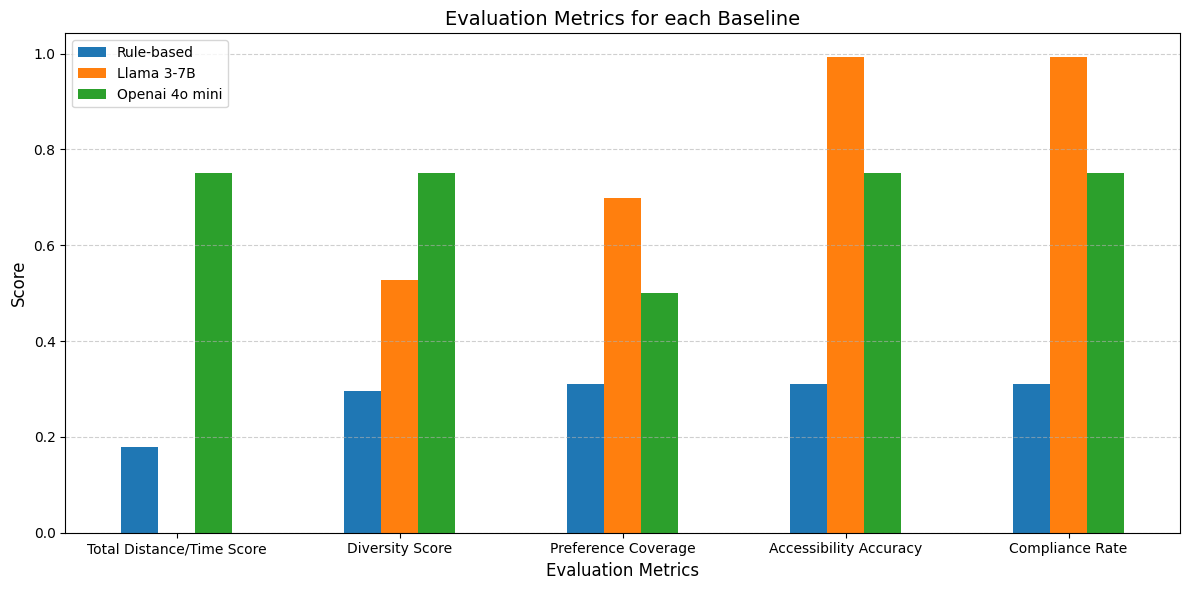

In [27]:
# manually copied baseline 2, 3 for now
baseline_data = [
    list(avg),
    [0, 0.5275, 0.6975, 0.9925, 0.9925], # baseline 2
    [0.75, 0.75, 0.5, 0.75, 0.75] # baseline 3
]

df = pd.DataFrame(baseline_data)
df.columns = ['Total Distance/Time Score', 'Diversity Score', 'Preference Coverage', 'Accessibility Accuracy', 'Compliance Rate']

df_transposed = df.T 
df_transposed.columns = ['Rule-based', 'Llama 3-7B', 'Openai 4o mini']

plt.figure(figsize=(12, 6))
ax = df_transposed.plot(kind='bar', ax=plt.gca())

plt.title('Evaluation Metrics for each Baseline', fontsize=14)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# plt.savefig('grouped_bar_plot.png')